<a href="https://colab.research.google.com/github/edwardsnj/glygen-colab-notebooks/blob/main/variants/main1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [156]:
#
# Import the modules from the github repository
#
import httpimport

with httpimport.github_repo("edwardsnj","glygen-colab-notebooks", ref="main"):
  from glygen import GlyGenDownloader


In [157]:
#
# Parameters for the figure
#

SPECIES = "human"

# SITETYPE = "predicted"
SITETYPE = "experimental"

VARTYPE = "somatic"
# VARTYPE = "germline"

GLYCOTYPE = "N-linked"
# GLYCOTYPE = "O-linked"

In [158]:
#
# Make lists of GlyGen reviewed data-files for species-specific glycosites
# using the GlyGenDownloader class
#

ggdl = GlyGenDownloader()

# UniProt is a mix of experimental and predicted
template = "{species}_proteoform_glycosylation_sites_uniprotkb.csv"
uniprotkb_site_files = ggdl.filenames(template,species=SPECIES)

# Some data-files have predicted sites
template = "{species}_proteoform_glycosylation_sites_predicted_*.csv"
pred_site_files = ggdl.filenames(template,species=SPECIES)

# The rest (not uniprot, not predicted) are experimental sites
template = "{species}_proteoform_glycosylation_sites_*.csv"
site_files = ggdl.filenames(template,species=SPECIES)

exp_site_files = sorted(set(site_files)-set(pred_site_files)-set(uniprotkb_site_files))


In [159]:
#
# Use the GlyGenDownloader to construct data-frames for each of these classes
# of GlyGen reviewed data-files. Set the predicted column appropraitely.
#

params = {
  "usecols": ["uniprotkb_canonical_ac","start_pos","start_aa","glycosylation_type"],
  "notna": ["uniprotkb_canonical_ac","start_pos"],
  "asint": ["start_pos"],
  "dropdups": True,
  "setcolumn": {"predicted": False}
}
glyco_site_exp = ggdl.cached_dataframe("glyco_site_exp",exp_site_files,**params)

params = {
  "usecols": ["uniprotkb_canonical_ac","start_pos","start_aa","glycosylation_type"],
  "notna": ["uniprotkb_canonical_ac","start_pos"],
  "asint": ["start_pos"],
  "dropdups": True,
  "setcolumn": {"predicted": True}
}
glyco_site_pred = ggdl.cached_dataframe("glyco_site_pred",pred_site_files,**params)

params = {
  "usecols": ["uniprotkb_canonical_ac","start_pos","start_aa",
              "glycosylation_type","xref_key"],
  "notna": ["uniprotkb_canonical_ac","start_pos"],
  "asint": ["start_pos"],
  "dropdups": True,
  "transform": {"predicted":
                lambda df: df["xref_key"].isin(["protein_xref_pubmed",
                                                "protein_xref_doi"])
                },
  "dropcols": ["xref_key"]
}
glyco_site_uniprotkb = ggdl.cached_dataframe("glyco_site_uniprotkb",uniprotkb_site_files,**params)


Reading cached data-frame glyco_site_exp...done. (34591 rows)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34591 entries, 0 to 34590
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   uniprotkb_canonical_ac  34591 non-null  object
 1   glycosylation_type      34591 non-null  object
 2   start_pos               34591 non-null  int64 
 3   start_aa                34591 non-null  object
 4   predicted               34591 non-null  bool  
dtypes: bool(1), int64(1), object(3)
memory usage: 1.1+ MB

Reading cached data-frame glyco_site_pred...done. (7125 rows)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7125 entries, 0 to 7124
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   uniprotkb_canonical_ac  7125 non-null   object
 1   glycosylation_type      7125 non-null   object
 2   start_pos              

In [160]:
#
# Concatenate the three data-frames, and subset
# on the predicted column, and then remove the
# predicted column
#

import pandas as pd

glyco_sites = pd.concat([glyco_site_exp,
                         glyco_site_pred,
                         glyco_site_uniprotkb],
                        ignore_index=True)
glyco_sites.drop_duplicates(inplace=True)
glyco_sites.reset_index(inplace=True,drop=True)

glyco_sites_exp = glyco_sites[~glyco_sites['predicted']]
glyco_sites_exp = glyco_site_exp.drop(columns=['predicted'])

glyco_sites_pred = glyco_sites[glyco_sites['predicted']]
glyco_sites_pred = glyco_site_pred.drop(columns=['predicted'])


In [161]:
#
# get mutations data, germline or somatic
#

template = "{species}_protein_mutation_cancer_all.csv"
cancer_files = ggdl.filenames(template,species=SPECIES)

template = "{species}_protein_mutation_germline_all.csv"
germline_files = ggdl.filenames(template,species=SPECIES)

params = {
  "usecols": ["uniprotkb_canonical_ac",
              "aa_pos","ref_aa","alt_aa",
              "do_name"],
  "notna": ["uniprotkb_canonical_ac","aa_pos","ref_aa"],
  "asint": ["aa_pos"],
  # "setcolumn": {"variant_type": "somatic_cancer"},
  "transform": {"dstatus": lambda df: ~df["do_name"].isna()},
  "filterrows": [ lambda df: (df["aa_pos"]>1),
                  lambda df: (df["ref_aa"] != df["alt_aa"]) ],
  "dropdups": True,
  "dropcols": ["do_name"]
}
cancer_df = ggdl.cached_dataframe("cancer_df",cancer_files,**params)

params = {
  "usecols": ["uniprotkb_canonical_ac",
              "begin_aa_pos","end_aa_pos","ref_aa","alt_aa",
              "do_id","mim_id"],
  "notna": ["uniprotkb_canonical_ac","begin_aa_pos","ref_aa"],
  "asint": ["begin_aa_pos","end_aa_pos"],
  # "setcolumn": {"variant_type": "germline"},
  "transform": {"aa_pos": lambda df: df["begin_aa_pos"],
                "dstatus": lambda df: (~df["do_id"].isna() & ~df["mim_id"].isna())
                },
  "filterrows": [ lambda df: (df["begin_aa_pos"]>1),
                  lambda df: (df["begin_aa_pos"] == df["end_aa_pos"]),
                  lambda df: (df["ref_aa"] != df["alt_aa"]) ],
  "dropdups": True,
  "dropcols": ["begin_aa_pos", "end_aa_pos", "do_id", "mim_id"]
}
germline_df = ggdl.cached_dataframe("germline_df",germline_files,**params)


Reading cached data-frame cancer_df...done. (3647883 rows)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3647883 entries, 0 to 3647882
Data columns (total 5 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   uniprotkb_canonical_ac  object
 1   aa_pos                  int64 
 2   ref_aa                  object
 3   alt_aa                  object
 4   dstatus                 bool  
dtypes: bool(1), int64(1), object(3)
memory usage: 114.8+ MB

Reading cached data-frame germline_df...done. (10946540 rows)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10946540 entries, 0 to 10946539
Data columns (total 5 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   uniprotkb_canonical_ac  object
 1   ref_aa                  object
 2   alt_aa                  object
 3   aa_pos                  int64 
 4   dstatus                 bool  
dtypes: bool(1), int64(1), object(3)
memory usage: 344.5+ MB



In [162]:
if GLYCOTYPE not in ("N-linked","O-linked"):
  raise ValueError("GLYCOTYPE must be 'N-linked' or 'O-linked'")

if SITETYPE == 'experimental':
  glyco_sites = glyco_sites_exp[glyco_sites_exp['glycosylation_type']==GLYCOTYPE]
elif SITETYPE == 'predicted':
  glyco_sites = glyco_sites_pred[glyco_sites_pred['glycosylation_type']==GLYCOTYPE]
else:
  raise ValueError("SITETYPE must be 'experimental' or 'predicted'")

if VARTYPE == "somatic":
  variants = cancer_df
elif VARTYPE == "germline":
  variants = germline_df
else:
  raise ValueError("VARTYPE must be 'somatic' or 'germline'")

print(f"SITETYPE: {SITETYPE}, VARTYPE: {VARTYPE}, GLYCOTYPE: {GLYCOTYPE}")
print(f"Glycosites: {glyco_sites.shape[0]}")
print(f"Variants: {variants.shape[0]}")

SITETYPE: experimental, VARTYPE: somatic, GLYCOTYPE: N-linked
Glycosites: 9722
Variants: 3647883


In [163]:
from tqdm import tqdm

upkbacc = list(set(variants['uniprotkb_canonical_ac']) & set(glyco_sites['uniprotkb_canonical_ac']))
print(f"UniProtKB Accessions: {len(upkbacc)}")

chsize = 100
merges = []
for i in tqdm(range(0,len(upkbacc),chsize)):
  upkb = upkbacc[i:i+chsize]
  df1 = glyco_sites[glyco_sites['uniprotkb_canonical_ac'].isin(upkb)]
  df2 = variants[variants['uniprotkb_canonical_ac'].isin(upkb)]
  # print(len(upkb),df1.shape[0],df2.shape[0])
  merged = pd.merge(df1,df2,on='uniprotkb_canonical_ac')
  merged['delta'] = (merged['start_pos']-merged['aa_pos'])
  merged = merged[merged['delta'].abs()<=20]
  merged = merged.drop(columns=['glycosylation_type','start_aa',
                                'ref_aa','alt_aa','dstatus'])
  merged = merged.drop_duplicates()
  merged = merged.reset_index(drop=True)
  # print(f"{len(upkb)} uniprot accessions have {merged.shape[0]} merged rows.")
  merges.append(merged)
merged = pd.concat(merges,ignore_index=True)
merged = merged.drop_duplicates()
merged = merged.reset_index(drop=True)
merged

UniProtKB Accessions: 3840


100%|██████████| 39/39 [00:09<00:00,  3.98it/s]


,uniprotkb_canonical_ac,start_pos,aa_pos,delta
0,P10253-1,390,404,-14
1,P10253-1,390,397,-7
2,P10253-1,390,406,-16
3,P10253-1,390,391,-1
4,P10253-1,390,394,-4
...,...,...,...,...
112968,P01019-1,38,26,12
112969,P01019-1,38,35,3
112970,P01019-1,38,55,-17
112971,P01019-1,38,32,6


In [164]:
from scipy.stats import binomtest

delta_counts = pd.DataFrame(merged[["delta"]].value_counts())
delta_counts = delta_counts.sort_values(by='delta')
delta_counts = delta_counts.reset_index()

N = delta_counts['count'].sum()
n = delta_counts.shape[0]
p = 1/n

for i in range(delta_counts.shape[0]):
  delta_counts.loc[i,'ratio'] = delta_counts.loc[i,'count']/N
  delta_counts.loc[i,'fc'] = delta_counts.loc[i,'ratio']/((1-delta_counts.loc[i,'ratio'])/(n-1))
  delta_counts.loc[i,'pvalue'] = binomtest(delta_counts.loc[i,'count'], N, p,
                                           alternative='two-sided').pvalue

delta_counts

,delta,count,ratio,fc,pvalue
0,-20,2698,0.023882,0.978644,2.716038e-01
1,-19,2852,0.025245,1.035951,6.407684e-02
2,-18,2746,0.024307,0.996489,8.697747e-01
3,-17,2751,0.024351,0.998349,9.461784e-01
4,-16,2824,0.024997,1.025520,1.864348e-01
5,-15,2814,0.024909,1.021796,2.591818e-01
6,-14,2850,0.025227,1.035206,6.835939e-02
7,-13,2798,0.024767,1.015838,4.123725e-01
8,-12,2825,0.025006,1.025892,1.800872e-01
9,-11,2800,0.024785,1.016583,3.907263e-01


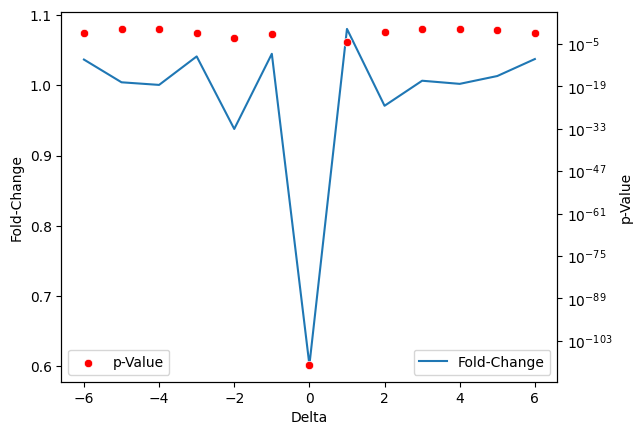

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

df = delta_counts[delta_counts['delta'].abs()<=6].set_index('delta')
df.sort_index(inplace=True)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax2.set_yscale('log')

sns.lineplot(df["fc"],ax=ax1,label="Fold-Change")
sns.scatterplot(df["pvalue"],ax=ax2,color='red',label="p-Value")
ax1.set_xlabel("Delta")
ax1.set_ylabel("Fold-Change")
ax2.set_ylabel("p-Value")
ax1.legend(loc='lower right')
ax2.legend(loc='lower left')
plt.show()